### Imports

In [19]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import sys
from pathlib import Path
import numpy as np
import math
pd.reset_option("display.precision")
pd.reset_option("display.float_format")
pd.set_option("display.max_columns", None)

In [20]:
### Changing to parent directory
current_file_path = Path("").resolve()
grandparent_dir = current_file_path.parent.parent.parent
# Append this directory to the system path
sys.path.append(str(grandparent_dir))

### 1. Data

In [21]:
folder_path = os.path.join(grandparent_dir,"Raw Data - FeCN platinum 8")
filename = "CV3.dta"
file_path = os.path.join(folder_path,filename)

In [22]:
keep_cols = ["Pt","Vf", "Im"] #row number, voltage, current

with open(file_path, "r", encoding="ISO-8859-1") as f:
    content = f.readlines()
    for i,line in enumerate(content):
        if line.__contains__("CURVE"):
            index = i + 1 #finds line where datatable resides (below "CURVE" label)
            break
    content = content[index:]
        
    # Read the remaining lines and create a DataFrame
    df = pd.DataFrame([line.split('\t') for line in content if line.strip()])
    df = df.map(lambda x: x.strip() if isinstance(x, str) else x) # Remove newline characters from the last column
    df = df.drop(0, axis=1) # Drop the first column (column zero)
    df.columns = df.iloc[0] # Set the header names using the values from the first row
    df = df.drop(0) # Drop the first row (since it's now used as header)
    df = df.iloc[1:] # Drops row with units
    df = df[keep_cols]
    df["Vf"] = pd.to_numeric(df["Vf"], errors="coerce")
    df["Im"] = pd.to_numeric(df["Im"], errors="coerce")
    df = df.dropna(how='all')
    df = df.reset_index(drop=True)

#Creates a Cycle Number Column (Cycles 1-4)
df["Cycle Num"] = (df["Pt"] == "TABLE").cumsum() + 1
dfs = {}
for i in range(1,5):
    if i == 1:
        dfs[f"cycle{i}"] = df[df["Cycle Num"] ==i]
    else:
        temp_df = df[df["Cycle Num"] ==i]
        temp_df = temp_df.iloc[3:] # Drop the first row after headers are assigned
        dfs[f"cycle{i}"] = temp_df

### 2. Filtering to Stable Cycle 3

In [23]:
df_plot = dfs["cycle3"]
df_plot["Im"] = df_plot["Im"] * 10**6
df_plot

,Pt,Vf,Im,Cycle Num
2107,2101,-0.299055,-7.86044,3
2108,2102,-0.298070,-7.81824,3
2109,2103,-0.297069,-7.77991,3
2110,2104,-0.296069,-7.74429,3
2111,2105,-0.295065,-7.71009,3
...,...,...,...,...
3302,3296,-0.296053,-7.92006,3
3303,3297,-0.297032,-7.91021,3
3304,3298,-0.298046,-7.90256,3
3305,3299,-0.299042,-7.89440,3


### 3. Plots

#### Functions

In [24]:
def ray_polyline_intersection(p0, p1, bound_x_vals, bound_y_vals, t_min=1e-6):
    """First intersection of ray p0 -> direction (p1-p0) with polyline (xs,ys).
       Returns (t, x, y) of the closest hit with t > t_min, or None."""
    x0, y0 = p0
    dx_l, dy_l = p1[0] - x0, p1[1] - y0
    hits = []
    for i in range(len(bound_x_vals) - 1):
        xa, ya = bound_x_vals[i], bound_y_vals[i]
        xb, yb = bound_x_vals[i+1], bound_y_vals[i+1]
        dxs, dys = xb - xa, yb - ya
        denom = dx_l * (-dys) - dy_l * (-dxs)
        if abs(denom) < 1e-15:
            continue
        t = ((xa - x0) * (-dys) - (ya - y0) * (-dxs)) / denom
        s = (dx_l * (ya - y0) - dy_l * (xa - x0)) / denom
        if 0 <= s <= 1 and t > t_min:
            hits.append((t, x0 + t * dx_l, y0 + t * dy_l))
    if not hits:
        return None
    hits.sort()
    return hits[0]  # (t, x, y)

def extend_to_bounds(p_peak, p_center, x_min, x_max, y_min, y_max,
                     curve_xs=None, curve_ys=None):
    """Extend the line from p_peak through p_center, stopping at whichever comes first:
       (a) the next intersection with the CV curve (if curve_xs/ys given), or
       (b) the bounding box edge."""
    x0, y0 = p_peak
    xc, yc = p_center
    dx, dy = xc - x0, yc - y0
    # parametric line: (x0 + t*dx, y0 + t*dy); t=0 at peak, t=1 at center, t>1 beyond
    # bounding box t-values past the center
    ts = []
    if dx != 0:
        ts.append((x_min - x0) / dx)
        ts.append((x_max - x0) / dx)
    if dy != 0:
        ts.append((y_min - y0) / dy)
        ts.append((y_max - y0) / dy)
    ts = [t for t in ts if t > 1]
    t_box = min(ts) if ts else None
    # curve-crossing t (must be strictly past the center)
    t_curve = None
    if curve_xs is not None and curve_ys is not None:
        hit = ray_polyline_intersection((x0, y0), (xc, yc), curve_xs, curve_ys,
                                        t_min=1.0 + 1e-6)
        if hit is not None:
            t_curve = hit[0]
    # pick the closer of the two
    candidates = [t for t in (t_box, t_curve) if t is not None]
    t_end = min(candidates)
    return x0 + t_end * dx, y0 + t_end * dy

def rotate_ccw_visual(p_from, p_to, angle_deg, ax):
    """Rotate vector p_from->p_to by angle_deg CCW in DISPLAY (pixel) space.
       Returns the rotated point in DATA coordinates."""
    inv = ax.transData.inverted()
    p_from_disp = ax.transData.transform(p_from)
    p_to_disp = ax.transData.transform(p_to)
    vx, vy = p_to_disp - p_from_disp
    theta = np.deg2rad(angle_deg)
    rx = np.cos(theta) * vx - np.sin(theta) * vy
    ry = np.sin(theta) * vx + np.cos(theta) * vy
    p_rot_disp = p_from_disp + np.array([rx, ry])
    return inv.transform(p_rot_disp)

### TOC Graphic CV

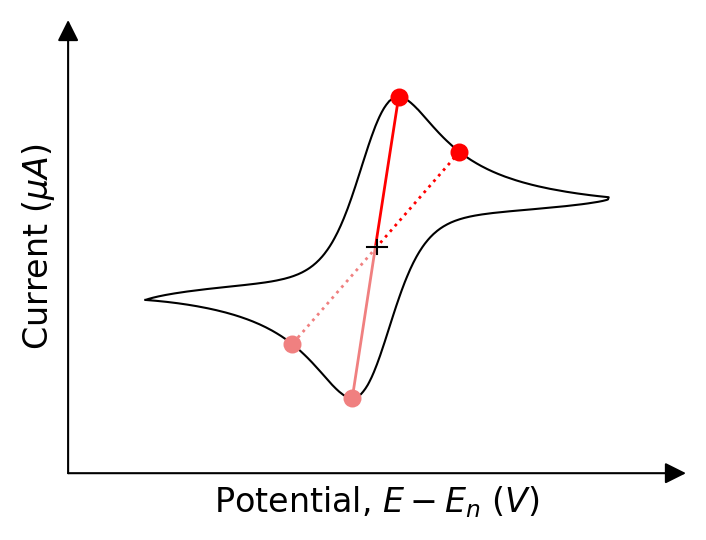

In [25]:
#Create Figure
plt.figure(figsize=(3.33,2.5),dpi=200) #7,5
ax = plt.gca()
for location in ['left', 'right', 'top', 'bottom']:
    ax.spines[location].set_visible(False)

# Plot CV
ax.plot(df_plot["Vf"], df_plot["Im"], linewidth=0.75, color="black")

# Peaks and half-wave center
idx_max = df_plot["Im"].idxmax()
idx_min = df_plot["Im"].idxmin()
x_anodic, y_anodic = df_plot.loc[idx_max, "Vf"], df_plot.loc[idx_max, "Im"]
x_cathodic, y_cathodic = df_plot.loc[idx_min, "Vf"], df_plot.loc[idx_min, "Im"]
x_E_center = (x_anodic + x_cathodic) / 2
x_center = 0
y_center = 0

# CV data extents
x_data_min = df_plot["Vf"].min()
x_data_max = df_plot["Vf"].max()
y_data_min = df_plot["Im"].min()
y_data_max = df_plot["Im"].max()

# Full CV outline as a polyline (in plot order)
df_sorted_full = df_plot.sort_values("Pt").reset_index(drop=True)
cv_xs = df_sorted_full["Vf"].values
cv_ys = df_sorted_full["Im"].values

#Plotting Peak Lines
ax.plot([x_anodic, x_E_center], [y_anodic, y_center], color="red", linewidth=1)
ax.scatter([x_anodic], [y_anodic], color="red", s=30, zorder=5)
ax.plot([x_E_center, x_cathodic], [y_center, y_cathodic], color="lightcoral", linewidth=1)
ax.scatter([x_cathodic], [y_cathodic], color="lightcoral", s=30, zorder=5)

# Plotting 60 Degree Line
deg = -30
turn_idx = df_sorted_full["Vf"].idxmax()
anodic_branch = df_sorted_full.iloc[:turn_idx + 1]
anodic_x_vals = anodic_branch["Vf"].values
anodic_y_vals = anodic_branch["Im"].values
p_rot = rotate_ccw_visual((x_center, y_center), (x_anodic, y_anodic), deg, ax)
anodic_end = ray_polyline_intersection((x_center, y_center), p_rot, anodic_x_vals, anodic_y_vals)
_, x_rot_anodic_end, y_rot_anodic_end = anodic_end
ax.plot([x_rot_anodic_end, x_center], [y_rot_anodic_end, y_center], color="red", linewidth=1,linestyle = ":")
ax.scatter([x_rot_anodic_end], [y_rot_anodic_end], color="red", s=30, zorder=5)
rot_cathodic_end = extend_to_bounds((x_rot_anodic_end, y_rot_anodic_end), (x_center, y_center),
                        x_data_min, x_data_max, y_data_min, y_data_max,
                        cv_xs, cv_ys)
ax.plot([x_center, rot_cathodic_end[0]], [y_center, rot_cathodic_end[1]], color="lightcoral", linewidth=1,linestyle = ":")
ax.scatter([rot_cathodic_end[0]], [rot_cathodic_end[1]], color="lightcoral", s=30, zorder=5)

# Draw axes as arrows
arrow_style = dict(arrowstyle='-|>', color='black', linewidth=0.75,
                   mutation_scale=16, shrinkA=0, shrinkB=0)
ax.annotate('', xy=(1, 0), xytext=(0, 0), xycoords='axes fraction',
            arrowprops=arrow_style)
ax.annotate('', xy=(0, 1), xytext=(0, 0), xycoords='axes fraction',
            arrowprops=arrow_style)

# Axis Formatting
ax.set_xlabel(rf"Potential, $E-E_n$ ($V$)",fontsize=12)
ax.set_ylabel(rf"Current ($\mu A$)",fontsize=12)
ax.set_xlim([-0.4,0.4])
ax.set_ylim([-33.5,33.5])
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(which='both', length=0)

# Plotting Center Cross at half-wave potential
dx_c = 0.0125
ax_ratio = (ax.get_xlim()[1] - ax.get_xlim()[0]) / (ax.get_ylim()[1] - ax.get_ylim()[0])
dy_c = dx_c / ax_ratio
ax.plot([x_center - dx_c, x_center + dx_c], [y_center, y_center], color="black", linewidth=0.75)
ax.plot([x_center, x_center], [y_center - dy_c, y_center + dy_c], color="black", linewidth=0.75)

#Saving Plot
plt.tight_layout(pad=0)
plt.savefig(f"Cover_art_CV.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()

### CV Figure

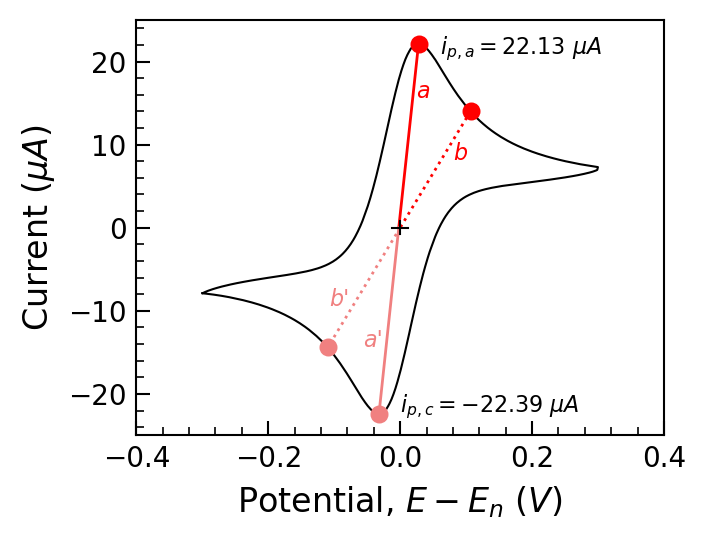

In [26]:
#Create Figure
plt.figure(figsize=(3.33,2.5),dpi=200) #7,5
ax = plt.gca()
for location in ['left', 'right', 'top', 'bottom']:
    ax.spines[location].set_linewidth(0.75)
idx_max = df_plot["Im"].idxmax()
idx_min = df_plot["Im"].idxmin()
x_max = df_plot.loc[idx_max, "Vf"]
y_max = df_plot.loc[idx_max, "Im"]
x_min = df_plot.loc[idx_min, "Vf"]
y_min = df_plot.loc[idx_min, "Im"]    

# Plot CV
ax.plot(df_plot["Vf"], df_plot["Im"], linewidth=0.75, color="black")
ax.scatter([x_min,x_max], [y_min,y_max], linewidth=1, color="black",s=10) #plots min/max points
ax.text(
    0.73, 0.93, f"$i_{{p,a}} = {round(y_max,3)}$ $\mu A$", transform=ax.transAxes, fontsize=8,
    color="black", va='center', ha='center', fontweight='medium'
)
ax.text(
    0.67, 0.07, f"$i_{{p,c}} = {round(y_min,3)}$ $\mu A$", transform=ax.transAxes, fontsize=8,
    color="black", va='center', ha='center', fontweight='medium'
)

# Major locator for ticks/grid
x_axis_tick = 0.2 #x-axis tick increments
y_axis_tick = 10 #y-axis tick increments
ax.xaxis.set_major_locator(ticker.MultipleLocator(x_axis_tick))
ax.yaxis.set_major_locator(ticker.MultipleLocator(y_axis_tick))
ax.minorticks_on()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(x_axis_tick/5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(y_axis_tick/5))
ax.tick_params(which='minor', labelbottom=False, labelleft=False, direction='in',
               length = 3, width = 0.6, color = 'black')
ax.tick_params(which='major', direction='in', labelsize=10,length=5,width=0.75)

# Axis Formatting
ax.set_xlabel(rf"Potential, $E-E_n$ ($V$)",fontsize=12)
ax.set_ylabel(rf"Current ($\mu A$)",fontsize=12)
ax.set_xlim([-0.4,0.4])
ax.set_ylim([-25,25])

#Plotting Line Segmenents
    #anodic peak segment (solid)
ax.plot([x_anodic, x_E_center], [y_anodic, y_center], color="red", linewidth=1)
ax.scatter([x_anodic], [y_anodic], color="red", s=30, zorder=5)
    #rotated anodic segment (dotted)
ax.plot([x_rot_anodic_end, x_center], [y_rot_anodic_end, y_center], color="red", linewidth=1,linestyle = ":")
ax.scatter([x_rot_anodic_end], [y_rot_anodic_end], color="red", s=30, zorder=5)
    #cathodic peak segement (solid)
ax.plot([x_E_center, x_cathodic], [y_center, y_cathodic], color="lightcoral", linewidth=1)
ax.scatter([x_cathodic], [y_cathodic], color="lightcoral", s=30, zorder=5)
    #rotated cathodic segment (dotted)
ax.plot([x_center, rot_cathodic_end[0]], [y_center, rot_cathodic_end[1]], color="lightcoral", linewidth=1,linestyle = ":")
ax.scatter([rot_cathodic_end[0]], [rot_cathodic_end[1]], color="lightcoral", s=30, zorder=5)


# Segment labels (a, a', b, b') — manual placement in axes-fraction coords
label_specs = [
    # (label, x_frac, y_frac, color)
    ("a",  0.53, 0.8, "red"),
    ("a'", 0.43, 0.2, "lightcoral"),
    ("b",  0.6, 0.65, "red"),
    ("b'", 0.365, 0.30, "lightcoral"),
]
for label, xf, yf, color in label_specs:
    ax.text(xf, yf, label, transform=ax.transAxes,
            fontsize=8, color=color, fontstyle="italic",
            ha="left", va="bottom")


# Plotting Center Cross at half-wave potential
dx_c = 0.0125
ax_ratio = (ax.get_xlim()[1] - ax.get_xlim()[0]) / (ax.get_ylim()[1] - ax.get_ylim()[0])
dy_c = dx_c / ax_ratio
ax.plot([x_center - dx_c, x_center + dx_c], [y_center, y_center], color="black", linewidth=0.75)
ax.plot([x_center, x_center], [y_center - dy_c, y_center + dy_c], color="black", linewidth=0.75)

#Saving Plot
plt.tight_layout(pad=0)
plt.savefig(f"Figure1_Pt_Cycle3_CV.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()


In [28]:
# CV endpoints of the four red/coral markers
a_dist = math.hypot(x_anodic - x_center, y_anodic - y_center)
ap_dist = math.hypot(x_cathodic - x_center, y_cathodic - y_center)
b_dist = math.hypot(x_rot_anodic_end - x_center, y_rot_anodic_end - y_center)
bp_dist = math.hypot(rot_cathodic_end[0] - x_center, rot_cathodic_end[1] - y_center)
print("┌─────────────────────────────────────────────────────────────────┐")
print("│                         CV Endpoints                            │")
print("├──────────────────────────────────┬───────────┬──────────────────┤")
print("│ Point                            │   E (V)   │    i (µA)        │")
print("├──────────────────────────────────┼───────────┼──────────────────┤")
print(f"│ Anodic peak           (red)      │ {x_anodic:>+8.5f}  │ {y_anodic:>+12.3f}     │")
print(f"│ Cathodic peak         (coral)    │ {x_cathodic:>+8.5f}  │ {y_cathodic:>+12.3f}     │")
print(f"│ Rotated anodic point  (red)      │ {x_rot_anodic_end:>+8.5f}  │ {y_rot_anodic_end:>+12.3f}     │")
print(f"│ Rotated cathodic point (coral)   │ {rot_cathodic_end[0]:>+8.5f}  │ {rot_cathodic_end[1]:>+12.3f}     │")
print("└──────────────────────────────────┴───────────┴──────────────────┘")

print("\n┌─────────────────────────────────────────────────────────────────┐")
print("│        Segment Lengths  (center → endpoint, √(V² + µA²))        │")
print("├──────────────────────────────────────────────┬──────────────────┤")
print("│ Segment                                      │     Length       │")
print("├──────────────────────────────────────────────┼──────────────────┤")
print(f"│ a   Anodic peak           → center  (─ red)  │ {a_dist:>12.3f}     │")
print(f"│ a'  Cathodic peak         → center  (─ coral)│ {ap_dist:>12.3f}     │")
print(f"│ b   Rotated anodic point  → center  (⋯ red)  │ {b_dist:>12.3f}     │")
print(f"│ b'  Rotated cathodic point → center (⋯ coral)│ {bp_dist:>12.3f}     │")
print("└──────────────────────────────────────────────┴──────────────────┘")

┌─────────────────────────────────────────────────────────────────┐
│                         CV Endpoints                            │
├──────────────────────────────────┬───────────┬──────────────────┤
│ Point                            │   E (V)   │    i (µA)        │
├──────────────────────────────────┼───────────┼──────────────────┤
│ Anodic peak           (red)      │ +0.02793  │      +22.130     │
│ Cathodic peak         (coral)    │ -0.03208  │      -22.390     │
│ Rotated anodic point  (red)      │ +0.10671  │      +14.008     │
│ Rotated cathodic point (coral)   │ -0.10978  │      -14.412     │
└──────────────────────────────────┴───────────┴──────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│        Segment Lengths  (center → endpoint, √(V² + µA²))        │
├──────────────────────────────────────────────┬──────────────────┤
│ Segment                                      │     Length       │
├──────────────────────────────────────────────